# NVDA GARCH(1,1) Benchmark: Intraday Volatility Forecasting

**Author:** Ayooluwa Adelagun

**Date:** March 2026

---

## Overview

This notebook implements a **GARCH(1,1)** model as the econometric benchmark for forecasting daily realised intraday volatility of NVIDIA Corporation (NVDA).

GARCH(1,1) models the conditional variance of log returns as:

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

where $\omega$ is a constant, $\alpha$ captures the immediate impact of return shocks, and $\beta$ captures the persistence of prior variance.

### Forecasting Strategy

An **expanding window** approach is used: the model is re-estimated at each step using all available data up to time $t$, then produces a one-step-ahead conditional variance forecast for $t+1$. This avoids lookahead bias and allows the model to adapt to changing volatility regimes over time.

### Pipeline Summary
1. Load dataset and define train/test split (matching the 80/20 chronological split used in the ML pipeline)
2. Compute empirical scale factor to align GARCH conditional volatility with the `Daily Volatility` target
3. Fit GARCH(1,1) with Student's t-distribution on the training set
4. Report in-sample diagnostics (parameter significance, residual autocorrelation)
5. Generate expanding-window one-step-ahead forecasts over the test set
6. Evaluate forecasts against realised volatility using RMSE and QLIKE
7. Derive binary directional predictions from GARCH forecasts
8. Evaluate classification performance: Accuracy, Precision, Sensitivity, Specificity, AUC
9. Visualise forecasts vs. actuals and save results for downstream comparison

### Design Decisions
- **Target variable**: `Daily Volatility` (RMS of intraday hourly log returns, decimal units)
- **GARCH input**: daily log returns (`Return` column × 100) — GARCH requires a return series, not a volatility series, for stable MLE convergence
- **Scale factor**: empirical median ratio of `Daily Volatility` to GARCH conditional volatility, computed on the training set, ensures forecasts are in the same units as the target without hardcoding
- **Distribution**: Student's t, more appropriate than normal for individual stock returns, which exhibit fat tails
- **Forecast output**: $\sqrt{\hat{\sigma}_t^2} / 100 \times$ scale factor (conditional volatility rescaled to decimal Daily Volatility units)
- **Window**: expanding (all data up to $t$ used for each re-estimation)
- **Directional prediction**: GARCH is not a classifier by design; a binary signal is derived by comparing each one-step-ahead forecast against the last observed volatility value, consistent with the binary target definition used throughout this project

---
## 1. Imports

In [1]:
!pip install arch

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)

---
## 2. Load Data & Define Train/Test Split

The same chronological 80/20 split used in the ML pipeline is applied here to ensure all models are evaluated over an identical out-of-sample period.

In [3]:
CSV_PATH = '/Users/HP/Downloads/NVDA Datasets/Dataset Contruction/NVDA_Intraday_Volatility_Dataset_VIX.csv'

data = pd.read_csv(CSV_PATH, index_col='Date', parse_dates=True)

print(f'Total rows:   {len(data):,}')
print(f'Date range:   {data.index.min().date()} to {data.index.max().date()}')
print(f'Columns:      {list(data.columns)}')
print(data.head())

Total rows:   5,323
Date range:   2005-01-03 to 2026-03-02
Columns:      ['Return_Squared', 'Return', 'Range', 'Volume', 'VIX', 'Daily Volatility', 'target']
            Return_Squared    Return   Range        Volume    VIX  \
Date                                                                
2005-01-03        0.000001  0.001018  0.0103  1.066716e+09  14.08   
2005-01-04        0.002351 -0.048485  0.0140  7.902240e+08  13.98   
2005-01-05        0.000092  0.009569  0.0070  7.248120e+08  14.09   
2005-01-06        0.000092 -0.009569  0.0088  5.635680e+08  13.58   
2005-01-07        0.000377 -0.019418  0.0082  7.630920e+08  13.49   

            Daily Volatility  target  
Date                                  
2005-01-03          0.012517       1  
2005-01-04          0.011489       0  
2005-01-05          0.013424       1  
2005-01-06          0.007803       0  
2005-01-07          0.012123       1  


In [4]:
# Chronological 80/20 split — identical to ML pipeline
split_idx = int(len(data) * 0.8)
train = data.iloc[:split_idx].copy()
test  = data.iloc[split_idx:].copy()

print(f'Training rows: {len(train):,}  ({train.index.min().date()} to {train.index.max().date()})')
print(f'Test rows:     {len(test):,}   ({test.index.min().date()} to {test.index.max().date()})')

# GARCH input: Return * 100 (standard practice — avoids MLE numerical instability
# that arises from fitting GARCH on a volatility series directly)
returns_full  = data['Return'] * 100
returns_train = train['Return'] * 100
returns_test  = test['Return'] * 100

# Realised volatility target (decimal units)
rv_test = test['Daily Volatility']

Training rows: 4,258  (2005-01-03 to 2021-11-30)
Test rows:     1,065   (2021-12-01 to 2026-03-02)


---
## 3. Initial GARCH(1,1) Fit & Scale Factor Computation

A GARCH(1,1) model with Student's t-distribution is fitted on the training set.
Student's t is chosen over the normal distribution because individual stock returns
typically exhibit fat tails — a property well-documented for NVDA.

### Scale Factor
GARCH is fitted on `Return * 100`, so conditional volatility is expressed in percentage units.
The target `Daily Volatility` is in decimal units and represents the RMS of intraday hourly
log returns — a different quantity from the daily return standard deviation.

An **empirical scale factor** is computed as the median ratio of `Daily Volatility` to
GARCH conditional volatility (both from the training set). This data-driven conversion
avoids hardcoding and ensures forecasts are directly comparable to the target.

The fitted model is also used to:
- Inspect parameter estimates and their significance
- Confirm that $\alpha + \beta < 1$ (stationarity condition)
- Validate model assumptions via residual diagnostics

In [5]:
# Specify GARCH(1,1) with Student's t-distribution
garch_model = arch_model(
    returns_train,
    p=1, q=1,
    mean='constant',
    vol='GARCH',
    dist='t'
)

garch_fit = garch_model.fit(disp='off')
print(garch_fit.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -9970.13
Distribution:      Standardized Student's t   AIC:                           19950.3
Method:                  Maximum Likelihood   BIC:                           19982.0
                                              No. Observations:                 4258
Date:                      Mon, Apr 27 2026   Df Residuals:                     4257
Time:                              16:42:27   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [6]:
# Extract and report parameter estimates
params = garch_fit.params
omega = params['omega']
alpha = params['alpha[1]']
beta  = params['beta[1]']

print('--- GARCH(1,1) Parameter Estimates ---')
print(f'omega (constant):   {omega:.6f}')
print(f'alpha (ARCH term):  {alpha:.6f}  — immediate impact of return shocks')
print(f'beta  (GARCH term): {beta:.6f}  — persistence of prior variance')
print(f'alpha + beta:       {alpha + beta:.6f}  (must be < 1 for stationarity)')

long_run_var = omega / (1 - alpha - beta)
long_run_vol = np.sqrt(long_run_var)
print(f'\nLong-run variance: {long_run_var:.6f}')
print(f'Long-run volatility (% terms): {long_run_vol:.4f}%')

if alpha + beta >= 1:
    print('WARNING: alpha + beta >= 1 — model is non-stationary')
else:
    print('Stationarity condition satisfied.')

--- GARCH(1,1) Parameter Estimates ---
omega (constant):   0.042658
alpha (ARCH term):  0.049503  — immediate impact of return shocks
beta  (GARCH term): 0.948562  — persistence of prior variance
alpha + beta:       0.998065  (must be < 1 for stationarity)

Long-run variance: 22.041524
Long-run volatility (% terms): 4.6948%
Stationarity condition satisfied.


In [7]:
# Compute empirical scale factor on training set
# GARCH conditional vol is in % units; Daily Volatility is in decimal units
train_cond_vol_dec = garch_fit.conditional_volatility / 100
actual_train_dv    = train['Daily Volatility']

common_idx   = train_cond_vol_dec.index.intersection(actual_train_dv.index)
scale_factor = (actual_train_dv.loc[common_idx] / train_cond_vol_dec.loc[common_idx]).median()

print(f'Empirical scale factor (median ratio): {scale_factor:.6f}')
print(f'Interpretation: GARCH cond vol / 100 * {scale_factor:.4f} ≈ Daily Volatility')
print(f'\nVerification on training set:')
print(f'  GARCH mean cond vol (rescaled): {(train_cond_vol_dec * scale_factor).mean():.6f}')
print(f'  Daily Volatility mean:          {actual_train_dv.mean():.6f}')

Empirical scale factor (median ratio): 0.234904
Interpretation: GARCH cond vol / 100 * 0.2349 ≈ Daily Volatility

Verification on training set:
  GARCH mean cond vol (rescaled): 0.006716
  Daily Volatility mean:          0.007440


---
## 4. In-Sample Diagnostics

If GARCH is adequately capturing the volatility clustering in returns, the **standardised residuals** should resemble white noise — no remaining autocorrelation or clustering.

Two checks are performed:
1. **ACF plot** of standardised residuals (visual)
2. **Ljung-Box test** on standardised residuals (formal)

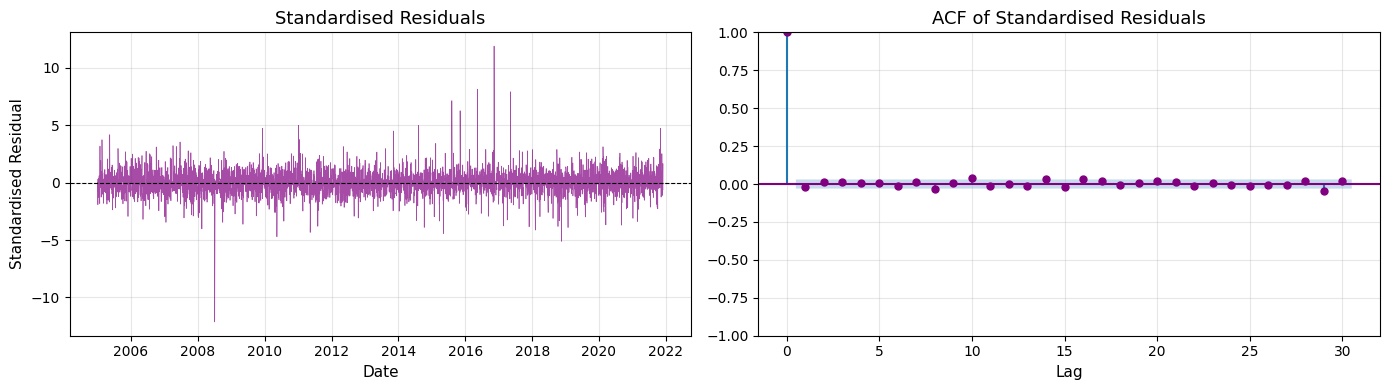

In [8]:
# Standardised residuals: residuals / conditional volatility
std_resid = garch_fit.resid / garch_fit.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: standardised residuals over time
axes[0].plot(std_resid.index, std_resid.values, color='purple', linewidth=0.5, alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Standardised Residuals', fontsize=13)
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Standardised Residual', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Right: ACF of standardised residuals
plot_acf(std_resid, lags=30, alpha=0.05, ax=axes[1], color='purple')
axes[1].set_title('ACF of Standardised Residuals', fontsize=13)
axes[1].set_xlabel('Lag', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('NVDA_GARCH_Diagnostics.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Ljung-Box test for remaining autocorrelation in standardised residuals
# H0: residuals are independently distributed (no autocorrelation)
# Reject H0 (p < 0.05) => autocorrelation remains => model may be inadequate
lb_test = acorr_ljungbox(std_resid, lags=10, return_df=True)
print('Ljung-Box Test on Standardised Residuals (lags 1-10):')
print(lb_test)
print()
min_pval = lb_test['lb_pvalue'].min()
if min_pval > 0.05:
    print(f'Minimum p-value: {min_pval:.4f} > 0.05 — no significant autocorrelation. Model assumptions satisfied.')
else:
    print(f'Minimum p-value: {min_pval:.4f} < 0.05 — residual autocorrelation detected.')

Ljung-Box Test on Standardised Residuals (lags 1-10):
      lb_stat  lb_pvalue
1    1.384809   0.239284
2    2.122366   0.346046
3    3.170908   0.366018
4    3.345794   0.501709
5    3.654207   0.600193
6    4.742599   0.577225
7    5.592481   0.588054
8   10.378928   0.239431
9   10.637502   0.301377
10  16.400271   0.088733

Minimum p-value: 0.0887 > 0.05 — no significant autocorrelation. Model assumptions satisfied.


---
## 5. Expanding-Window One-Step-Ahead Forecasts

Forecasts are generated using an **expanding window**:
- At each step $t$ in the test period, the model is re-estimated on all data from the start of the training set up to and including $t-1$
- A one-step-ahead conditional variance $\hat{\sigma}_t^2$ is produced
- The forecast is rescaled: $\hat{v}_t = \sqrt{\hat{\sigma}_t^2} / 100 \times$ scale\_factor to match `Daily Volatility` units
- A safety clamp replaces any exploding forecasts from occasional non-converged fits

This procedure exactly mirrors the walk-forward evaluation used for the ML models.

In [10]:
n_train = len(returns_train)
n_test  = len(returns_test)

garch_forecasts = []

print(f'Generating {n_test} expanding-window one-step-ahead forecasts...')
print('(This may take a few minutes — the model is re-fitted at each step)\n')

for i in range(n_test):
    # Expanding window: all data from start up to current test position
    window = returns_full.iloc[:n_train + i]

    # Re-specify and re-fit GARCH(1,1) with Student's t
    model  = arch_model(window, p=1, q=1, mean='constant', vol='GARCH', dist='t')
    result = model.fit(disp='off')

    # One-step-ahead variance forecast (in %²)
    var_forecast = result.forecast(horizon=1).variance.iloc[-1, 0]

    # Rescale to Daily Volatility units
    vol_forecast = (np.sqrt(var_forecast) / 100) * scale_factor

    # Safety clamp: replace exploding forecasts from non-converged fits
    if not np.isfinite(vol_forecast) or vol_forecast > 1.0:
        vol_forecast = garch_forecasts[-1] if garch_forecasts else train['Daily Volatility'].mean()

    garch_forecasts.append(vol_forecast)

    if (i + 1) % 50 == 0 or i == n_test - 1:
        print(f'  Step {i+1}/{n_test} complete')

# Align forecasts with test set dates
garch_forecast_series = pd.Series(
    garch_forecasts,
    index=test.index,
    name='GARCH_Forecast'
)

print(f'\nForecast generation complete.')
print(f'\nForecast stats:\n{garch_forecast_series.describe()}')
print(f'\nActual stats:\n{rv_test.describe()}')

Generating 1065 expanding-window one-step-ahead forecasts...
(This may take a few minutes — the model is re-fitted at each step)

  Step 50/1065 complete
  Step 100/1065 complete
  Step 150/1065 complete
  Step 200/1065 complete
  Step 250/1065 complete
  Step 300/1065 complete
  Step 350/1065 complete
  Step 400/1065 complete
  Step 450/1065 complete
  Step 500/1065 complete
  Step 550/1065 complete
  Step 600/1065 complete
  Step 650/1065 complete
  Step 700/1065 complete
  Step 750/1065 complete
  Step 800/1065 complete
  Step 850/1065 complete
  Step 900/1065 complete
  Step 950/1065 complete
  Step 1000/1065 complete
  Step 1050/1065 complete
  Step 1065/1065 complete

Forecast generation complete.

Forecast stats:
count    1065.000000
mean        0.007808
std         0.001998
min         0.004159
25%         0.005974
50%         0.008094
75%         0.009304
max         0.012922
Name: GARCH_Forecast, dtype: float64

Actual stats:
count    1065.000000
mean        0.007315
std     

---
## 6. Continuous Forecast Evaluation — RMSE and QLIKE

Two loss functions are computed on the continuous volatility forecasts:

**RMSE** (Root Mean Squared Error):
$$\text{RMSE} = \sqrt{\frac{1}{T} \sum_{t=1}^{T} (\sigma_t - \hat{\sigma}_t)^2}$$

**QLIKE** (Quasi-Likelihood loss — standard in the volatility forecasting literature):
$$\text{QLIKE} = \frac{1}{T} \sum_{t=1}^{T} \left[ \ln(\hat{\sigma}_t^2) + \frac{\sigma_t^2}{\hat{\sigma}_t^2} \right]$$

QLIKE is preferred in volatility research because it is robust to noise in realised volatility estimators and penalises forecast underprediction more heavily than overprediction.

In [11]:
actuals   = rv_test.values
forecasts = garch_forecast_series.values

# RMSE
rmse = np.sqrt(np.mean((actuals - forecasts) ** 2))

# QLIKE — computed on variances
eps      = 1e-10
act_var  = actuals   ** 2
fore_var = forecasts ** 2 + eps
qlike    = np.mean(np.log(fore_var) + act_var / fore_var)

print('=' * 45)
print('  GARCH(1,1) Continuous Forecast Results')
print('=' * 45)
print(f'  Test period:       {test.index.min().date()} to {test.index.max().date()}')
print(f'  Test observations: {len(test):,}')
print(f'  RMSE:              {rmse:.8f}')
print(f'  QLIKE:             {qlike:.6f}')
print('=' * 45)

  GARCH(1,1) Continuous Forecast Results
  Test period:       2021-12-01 to 2026-03-02
  Test observations: 1,065
  RMSE:              0.00363171
  QLIKE:             -8.623270


---
## 7. Forecast vs. Actuals Plot

Visualises the GARCH(1,1) one-step-ahead conditional volatility forecasts against the realised intraday volatility over the test period.

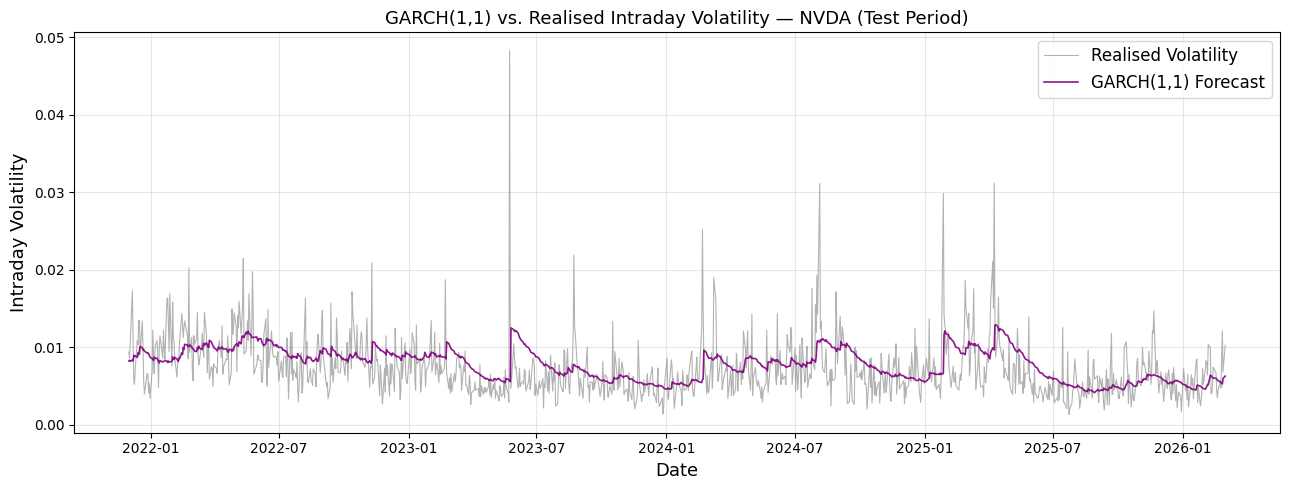

In [12]:
plt.figure(figsize=(13, 5))
plt.plot(test.index, actuals,   color='grey',   linewidth=0.8, alpha=0.6, label='Realised Volatility')
plt.plot(test.index, forecasts, color='purple', linewidth=1.2, alpha=0.9, label='GARCH(1,1) Forecast')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Intraday Volatility', fontsize=13)
plt.title('GARCH(1,1) vs. Realised Intraday Volatility — NVDA (Test Period)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('NVDA_GARCH_Forecast_vs_Actuals.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 8. Deriving Binary Directional Predictions

GARCH is not a classifier by design — it produces continuous conditional variance forecasts. A binary directional signal is derived by comparing each one-step-ahead forecast $\hat{v}_t$ against the last **observed** realised volatility $v_{t-1}$:

$$\hat{y}_t = \begin{cases} 1 & \text{if } \hat{v}_t > v_{t-1} \\ 0 & \text{otherwise} \end{cases}$$

This is consistent with the binary target definition used throughout this project:
$\text{target}_t = 1$ if $v_t > v_{t-1}$, else $0$.

The `prev_rv` values used for thresholding are the **actual** realised volatility values — i.e. $v_{t-1}$ is always the true observed value, not a GARCH estimate.

In [13]:
# Previous day's realised volatility for each test observation
rv_all  = data['Daily Volatility']
prev_rv = rv_all.shift(1).loc[test.index].values

# Fill NaN for first test observation with last training value
prev_rv[np.isnan(prev_rv)] = rv_all.iloc[split_idx - 1]

# Binary prediction: 1 if GARCH forecast > previous actual volatility, else 0
garch_binary = (forecasts > prev_rv).astype(int)

# True binary labels from the dataset
y_true = test['target'].values

print(f'GARCH predicted class 1 (increase): {garch_binary.sum():,} / {len(garch_binary):,} ({garch_binary.mean()*100:.1f}%)')
print(f'Actual class 1 (increase):           {y_true.sum():,} / {len(y_true):,} ({y_true.mean()*100:.1f}%)')

GARCH predicted class 1 (increase): 683 / 1,065 (64.1%)
Actual class 1 (increase):           518 / 1,065 (48.6%)


---
## 9. Classification Metrics

The binary GARCH predictions are evaluated using the same metrics as the RNN models:

- **Accuracy**: proportion of correct predictions
- **Precision**: of predicted increases, how many were correct
- **Sensitivity (Recall)**: of actual increases, how many were correctly identified
- **Specificity**: of actual decreases, how many were correctly identified
- **AUC**: area under the ROC curve — uses the raw GARCH forecast (normalised) as the probability score rather than the hard 0/1 prediction, giving a threshold-independent measure of discriminative ability

In [14]:
# Standard classification metrics
accuracy    = accuracy_score(y_true, garch_binary)
precision   = precision_score(y_true, garch_binary, zero_division=0)
sensitivity = recall_score(y_true, garch_binary, zero_division=0)

# Specificity = TN / (TN + FP)
tn, fp, fn, tp = confusion_matrix(y_true, garch_binary).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# AUC: use normalised continuous forecast as probability score
forecast_norm = (forecasts - forecasts.min()) / (forecasts.max() - forecasts.min() + 1e-10)
auc = roc_auc_score(y_true, forecast_norm)

print('=' * 55)
print('  GARCH(1,1) Classification Results (Out-of-Sample)')
print('=' * 55)
print(f'  Accuracy:    {accuracy:.3f}')
print(f'  Precision:   {precision:.3f}')
print(f'  Sensitivity: {sensitivity:.3f}')
print(f'  Specificity: {specificity:.3f}')
print(f'  AUC:         {auc:.2f}')
print('=' * 55)
print()
print('Confusion Matrix:')
print(f'  TN={tn}  FP={fp}')
print(f'  FN={fn}  TP={tp}')

  GARCH(1,1) Classification Results (Out-of-Sample)
  Accuracy:    0.667
  Precision:   0.619
  Sensitivity: 0.817
  Specificity: 0.525
  AUC:         0.48

Confusion Matrix:
  TN=287  FP=260
  FN=95  TP=423


---
## 10. ROC Curve

The ROC curve plots the true positive rate (sensitivity) against the false positive rate (1 - specificity) across all classification thresholds. The continuous GARCH volatility forecast is used as the score, so the curve reflects GARCH's inherent discriminative ability rather than the single hard threshold used above.

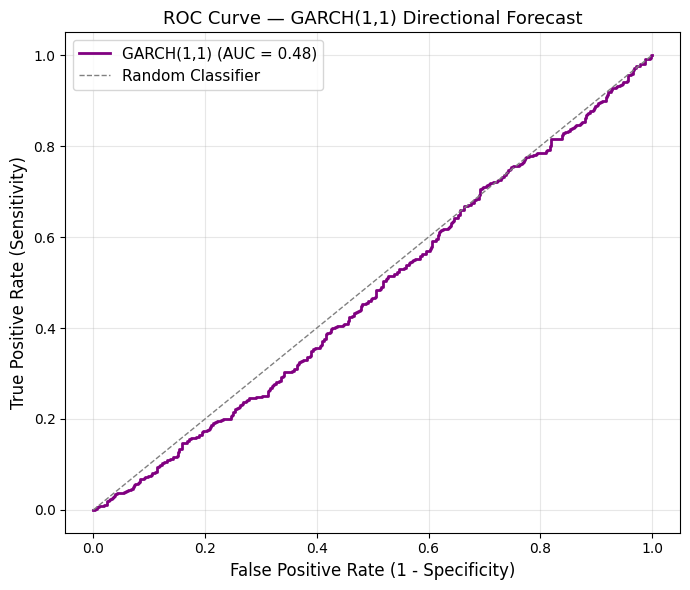

In [15]:
fpr, tpr, _ = roc_curve(y_true, forecast_norm)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='purple', linewidth=2, label=f'GARCH(1,1) (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linewidth=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve — GARCH(1,1) Directional Forecast', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('NVDA_GARCH_ROC.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 11. Save All Results for Downstream Comparison

The GARCH forecasts, binary predictions, and true labels are saved to CSV so they can be loaded alongside LSTM and GRU results in the final model comparison.

In [16]:
results_df = pd.DataFrame({
    'Realised_Volatility': actuals,
    'GARCH_Forecast':      forecasts,
    'GARCH_Binary':        garch_binary,
    'True_Target':         y_true
}, index=test.index)

results_df.to_csv('NVDA_GARCH_Forecasts.csv')
print('Saved to NVDA_GARCH_Forecasts.csv')
print(results_df.head(10))

# Summary table for dissertation
print('\n--- Summary for Dissertation Table ---')
print(f'{"Model":<14} | {"Accuracy":>8} | {"Precision":>9} | {"Sensitivity":>11} | {"Specificity":>11} | {"AUC":>5}')
print(f'{"GARCH(1,1)":<14} | {accuracy:>8.3f} | {precision:>9.3f} | {sensitivity:>11.3f} | {specificity:>11.3f} | {auc:>5.2f}')

Saved to NVDA_GARCH_Forecasts.csv
            Realised_Volatility  GARCH_Forecast  GARCH_Binary  True_Target
Date                                                                      
2021-12-01             0.009384        0.008254             0            0
2021-12-02             0.008636        0.008325             0            0
2021-12-03             0.010646        0.008190             0            1
2021-12-06             0.017307        0.008366             0            1
2021-12-07             0.010786        0.008247             0            0
2021-12-08             0.005615        0.008978             0            0
2021-12-09             0.005233        0.008814             1            0
2021-12-10             0.007186        0.008909             1            1
2021-12-13             0.010884        0.008703             1            1
2021-12-14             0.010342        0.009290             0            0

--- Summary for Dissertation Table ---
Model          | Accuracy 